# Runtime Curve Walkthrough: Hail x Solar

This notebook is a runnable walkthrough of the canonical `hail_solar` damage-curve artifact.

It is intentionally **M3-only**:

1. Read the canonical runtime JSON artifact.
2. Inspect the damage-code contract and evidence/provenance fields.
3. Evaluate the failure-unit damage-ratio curves.
4. Apply selector, conditioner, and exposure logic.
5. Show how a Hazard M3 consumer would assemble **conditional loss if hit** from an explicit value basis.

It does **not** calculate site hit probability, annual event frequency, EAL, PML, VaR, or TVaR. Those belong to the Hazard modeling tier after M2/M3 handoff.


## Mental Model

For this cell, the runtime chain is:

```text
public evidence + assumptions
  -> curated curve artifact
  -> selector chooses module archetype curve
  -> conditioner adjusts for event-time stow state
  -> exposure fraction scales value touched after a hit
  -> conditional loss if hit
```

Important separation:

- `p_hit` is a Hazard M2/M4 concept: did the storm footprint overlap the asset?
- `array_exposure_fraction` is a damage/value concept: after a hit, what fraction of the exposed PV module value is touched?
- `failure_unit_damage_ratio` is the curve output: what fraction of the PV module glass/cell failure-unit value is replaced at this hail size?

This notebook focuses on the last two bullets.


In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})


def find_repo_root(start: Path) -> Path:
    """Find the damage_modeling repo root from a notebook or repo working directory."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "docs/damage_curves").exists():
            return candidate
    raise RuntimeError("Could not find damage_modeling repo root from current working directory.")


REPO_ROOT = find_repo_root(Path.cwd())
CELL_DIR = REPO_ROOT / "docs/damage_curves/damage_curve_implementation/DAMAGE_CURVE_LIBRARY_V2_5_IMPLEMENTATION_HARDENED_DELIVERABLE/01_cells/hail_solar/current"
ARTIFACT_PATH = CELL_DIR / "hail_solar__model_v1_0__docs_r5__curve_artifact.json"
DOSSIER_PATH = CELL_DIR / "hail_solar_curve_derivation_dossier_v1_3.md"
METADATA_SPEC_PATH = CELL_DIR / "damage_code_metadata_spec_hail_solar_v1_3.md"
OUTPUT_DIR = REPO_ROOT / "notebooks/hail/solar/outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"repo root: {REPO_ROOT}")
print(f"artifact : {ARTIFACT_PATH.relative_to(REPO_ROOT)}")
print(f"outputs  : {OUTPUT_DIR.relative_to(REPO_ROOT)}")


repo root: /Users/divy/code/work/infrasure_git_codes/damage_modeling
artifact : docs/damage_curves/damage_curve_implementation/DAMAGE_CURVE_LIBRARY_V2_5_IMPLEMENTATION_HARDENED_DELIVERABLE/01_cells/hail_solar/current/hail_solar__model_v1_0__docs_r5__curve_artifact.json
outputs  : notebooks/hail/solar/outputs


## 1. Load The Canonical Runtime Artifact

The JSON artifact is the runtime contract. The dossier and workbook explain how it was derived; the artifact is what a consumer should pin and read.

The notebook asserts `canonical_runtime_artifact = true` so we do not accidentally inspect the legacy placeholder curve.


In [2]:
with ARTIFACT_PATH.open("r", encoding="utf-8") as f:
    artifact = json.load(f)

assert artifact["canonical_runtime_artifact"] is True, "This notebook must read the canonical runtime artifact."

identity_fields = [
    "schema_version",
    "cell_id",
    "damage_code_id",
    "semantic_damage_model_version",
    "documentation_revision",
    "package_release",
    "canonical_runtime_artifact",
    "source_dossier",
    "source_workbook",
]
identity = pd.DataFrame(
    [{"field": field, "value": artifact.get(field)} for field in identity_fields]
)
display(identity)

legacy = pd.DataFrame(artifact.get("known_noncanonical_legacy_artifacts", []))
if not legacy.empty:
    display(Markdown("**Known non-canonical artifacts to avoid:**"))
    display(legacy)


,field,value
0,schema_version,damage_curve_record_bundle.v1
1,cell_id,hail_solar
2,damage_code_id,HAIL_SOLAR_PV_MODULE_V1
3,semantic_damage_model_version,model v1.0
4,documentation_revision,docs r5
5,package_release,library v2.5
6,canonical_runtime_artifact,True
7,source_dossier,01_cells/hail_solar/current/hail_solar_curve_derivation_dossier_v1_3.md
8,source_workbook,01_cells/hail_solar/current/damage_curve_records_v1_3_hail_solar_derivation_audit.xlsx


**Known non-canonical artifacts to avoid:**

,artifact,status,reason
0,Hazard_modeling/data/hail/damage_curves/hail_solar_asset_capex_weighted.json,non_canonical_legacy_placeholder,Asset-level capex-weighted blend; does not match failure-unit grain or dossier parameters.


## 2. What The Curve Is Actually About

The cell is `hail_solar`, but the runtime curve is not a whole-asset hail curve. It is one primary nonzero failure-unit record:

```text
MESH-equivalent hail diameter -> PV_MODULE_GLASS_CELL replacement damage ratio
```

The value bucket is separate. A Hazard M3 consumer must apply the failure-unit DR only to the exposed PV module value bucket, not to the whole plant TIV.


In [3]:
hazard_axis = pd.DataFrame([artifact["hazard_axis"]])
failure_units = pd.DataFrame(artifact["failure_units"])

print("Hazard axis")
display(hazard_axis)

print("Failure units")
display(failure_units)


Hazard axis


,id,input_field,unit,source_units_allowed,valid_range,extrapolation_policy
0,HAIL_DIAMETER_MESH_EQUIV,mesh_diameter_mm,mm,"[mm, in]","[0, 100]",clamp_or_warn


Failure units


,id,subsystem,component,treatment,y_axis,value_bucket,f_kind
0,PV_MODULE_GLASS_CELL,PV_ARRAY,PV_MODULE,primary_nonzero,module replacement damage ratio approximated by glass breakage probability,PV_ARRAY_MODULE_EXPOSED,material_share


## 3. Runtime Evaluation Helpers

These helpers are deliberately small and transparent. They model the current artifact behavior:

- logistic base curve: `max_DR / (1 + exp(-k * (D - D50)))`
- selector: `module_archetype` chooses one curve record
- conditioner: stow blends unstowed and stowed curves
- exposure: `array_exposure_fraction` scales affected value, not fragility

Assumption note: the numeric stow adjustment is a documented placeholder in the artifact (`T4_placeholder_or_expert_judgment`). The notebook preserves that status and labels it in plots.


In [4]:
curve_records = pd.DataFrame([
    {
        "curve_id": rec["curve_id"],
        "failure_unit_id": rec["failure_unit_id"],
        "curve_form": rec["curve_form"],
        "module_archetype": rec["selector_match"]["module_archetype"],
        **rec["parameters"],
    }
    for rec in artifact["curve_records"]
])

curve_by_archetype = {
    rec["selector_match"]["module_archetype"]: rec
    for rec in artifact["curve_records"]
}
curve_by_id = {rec["curve_id"]: rec for rec in artifact["curve_records"]}


def logistic(mesh_diameter_mm, D50_mm, k_per_mm, max_DR=1.0):
    """Bounded monotone logistic failure-unit damage ratio."""
    d = np.asarray(mesh_diameter_mm, dtype=float)
    return max_DR / (1.0 + np.exp(-k_per_mm * (d - D50_mm)))


def select_curve_record(module_archetype=None):
    """Selector: fixed asset/module attributes choose the curve family."""
    default = next(
        item["default"]
        for item in artifact["selector_logic"]
        if item["field"] == "module_archetype"
    )
    selected = module_archetype or default
    if selected not in curve_by_archetype:
        allowed = sorted(curve_by_archetype)
        raise ValueError(f"Unknown module_archetype={selected!r}. Allowed: {allowed}")
    return curve_by_archetype[selected]


def stow_probability(stow_state, stow_success_probability=None):
    """Conditioner state probability, not hail frequency and not p_hit."""
    if stow_state in {"stowed", "confirmed_stowed"}:
        return 1.0
    if stow_state in {"unstowed", "confirmed_unstowed", "not_applicable"}:
        return 0.0
    if stow_state == "unknown_probabilistic":
        if stow_success_probability is None:
            raise ValueError("unknown_probabilistic stow_state requires stow_success_probability.")
        p = float(stow_success_probability)
        if not 0.0 <= p <= 1.0:
            raise ValueError("stow_success_probability must be between 0 and 1.")
        return p
    raise ValueError("stow_state must be stowed, unstowed, not_applicable, or unknown_probabilistic.")


def evaluate_failure_unit_dr(
    mesh_diameter_mm,
    module_archetype="default_3_2mm_glass_backsheet",
    stow_state="unstowed",
    stow_success_probability=None,
):
    """Evaluate scalar mean failure-unit DR for the selected curve and stow state."""
    rec = select_curve_record(module_archetype)
    params = rec["parameters"]
    base = logistic(
        mesh_diameter_mm,
        D50_mm=params["D50_mm"],
        k_per_mm=params["k_per_mm"],
        max_DR=params.get("max_DR", 1.0),
    )
    p_stowed = stow_probability(stow_state, stow_success_probability)

    # Artifact conditioner: 0.90 * logistic(D; D50 + 8mm, k).
    # This is explicitly T4 placeholder logic until tracker/BOM-specific evidence exists.
    stowed = logistic(
        mesh_diameter_mm,
        D50_mm=params["D50_mm"] + 8.0,
        k_per_mm=params["k_per_mm"],
        max_DR=0.90 * params.get("max_DR", 1.0),
    )
    conditioned = p_stowed * stowed + (1.0 - p_stowed) * base
    return conditioned


def exposure_default():
    row = next(item for item in artifact["exposure_logic"] if item["field"] == "array_exposure_fraction")
    return float(row["default"])


def evaluate_damage_code(payload):
    """Small consumer-style evaluator for this artifact.

    The artifact emits a failure-unit DR. Dollar loss requires a consumer-supplied value basis.
    """
    mesh = payload["mesh_diameter_mm"]
    module_archetype = payload.get("module_archetype", "default_3_2mm_glass_backsheet")
    stow_state = payload.get("stow_state", "unstowed")
    stow_success_probability = payload.get("stow_success_probability")
    exposure = float(payload.get("array_exposure_fraction", exposure_default()))
    if not 0.0 <= exposure <= 1.0:
        raise ValueError("array_exposure_fraction must be between 0 and 1.")

    failure_unit = artifact["failure_units"][0]
    value_bucket = failure_unit["value_bucket"]
    value_basis = payload.get("value_basis_usd", {})
    bucket_value = value_basis.get(value_bucket)

    dr = float(evaluate_failure_unit_dr(
        mesh,
        module_archetype=module_archetype,
        stow_state=stow_state,
        stow_success_probability=stow_success_probability,
    ))

    result = {
        "damage_code_id": artifact["damage_code_id"],
        "curve_id": select_curve_record(module_archetype)["curve_id"],
        "failure_unit_id": failure_unit["id"],
        "mesh_diameter_mm": mesh,
        "module_archetype": module_archetype,
        "stow_state": stow_state,
        "p_stowed_conditioner": stow_probability(stow_state, stow_success_probability),
        "array_exposure_fraction": exposure,
        "failure_unit_damage_ratio": dr,
        "value_bucket": value_bucket,
        "value_basis_usd": bucket_value,
        "conditional_loss_if_hit_usd": None,
        "metadata_flags": [],
    }
    if bucket_value is not None:
        result["conditional_loss_if_hit_usd"] = dr * exposure * float(bucket_value)
    if stow_state != "unstowed":
        result["metadata_flags"].append("STOW_ADJUSTMENT_PLACEHOLDER")
    if "array_exposure_fraction" not in payload:
        result["metadata_flags"].append("EXPOSURE_DEFAULT_USED")
    if "module_archetype" not in payload:
        result["metadata_flags"].append("DEFAULT_SELECTOR_USED")
    return result


display(curve_records)


,curve_id,failure_unit_id,curve_form,module_archetype,D50_mm,k_per_mm,max_DR
0,HAIL_SOLAR_FRAGILE_THIN_GG,PV_MODULE_GLASS_CELL,logistic,fragile_thin_glass_glass,41.074,0.220633,1.0
1,HAIL_SOLAR_DEFAULT_3P2_GBS,PV_MODULE_GLASS_CELL,logistic,default_3_2mm_glass_backsheet,52.696,0.165912,1.0
2,HAIL_SOLAR_HARDENED_THICKER,PV_MODULE_GLASS_CELL,logistic,hail_hardened_thicker_glass,64.114,0.135331,1.0


## 4. Evidence And Parameter Provenance In The Runtime Artifact

The runtime JSON does not embed every paragraph from the dossier. Instead it carries the parts a machine needs to audit the curve:

- parameter value
- parameter role
- evidence tier
- source IDs
- reasoning
- update trigger

This is the key difference from a bare curve table. The numbers are not floating around without provenance.


In [5]:
param_tiers = pd.DataFrame(artifact["parameter_tier_table"])
param_tiers["source_ids"] = param_tiers["source_ids"].apply(lambda xs: ", ".join(xs))
display(param_tiers)

rationale = pd.DataFrame([
    {"field": key, "value": value}
    for key, value in artifact["derivation_rationale"].items()
])
display(Markdown("**Derivation rationale carried by the artifact:**"))
display(rationale)


,parameter,curve_id,value,param_role,tier,source_ids,reasoning,update_trigger
0,D50_mm,HAIL_SOLAR_FRAGILE_THIN_GG,41.074000,curve_fit_shape,T2_public_lab_standard_or_physics,"PVEL_2023_HSS, KIWA_PVEL_HSS",Fit from public aggregate lab breakage anchors for thin glass/glass modules.,module-specific BOM or larger public lab dataset
1,k_per_mm,HAIL_SOLAR_FRAGILE_THIN_GG,0.220633,curve_fit_shape,T2_public_lab_standard_or_physics,"PVEL_2023_HSS, KIWA_PVEL_HSS",Logit-space fit to public lab anchors.,module-specific BOM or larger public lab dataset
2,D50_mm,HAIL_SOLAR_DEFAULT_3P2_GBS,52.696000,curve_fit_shape,T2_public_lab_standard_or_physics,"IEC_61215_BASELINE, PVEL_2023_HSS",Two-anchor fit using IEC near-zero baseline and public PVEL 50mm glass/backsheet aggregate.,claims/OEM/BOM-specific calibration
3,k_per_mm,HAIL_SOLAR_DEFAULT_3P2_GBS,0.165912,curve_fit_shape,T2_public_lab_standard_or_physics,"IEC_61215_BASELINE, PVEL_2023_HSS",Two-anchor logistic slope.,claims/OEM/BOM-specific calibration
4,D50_mm,HAIL_SOLAR_HARDENED_THICKER,64.114000,curve_fit_shape,T3_engineering_proxy_or_adjacent_empirical,"IEC_61215_BASELINE, PVEL_KIWA_HARDENED_PUBLIC_RESULT",Sparse-anchor hardened extrapolation; requires evidence of hardened module design.,hardened module-specific lab/claims data
5,k_per_mm,HAIL_SOLAR_HARDENED_THICKER,0.135331,curve_fit_shape,T3_engineering_proxy_or_adjacent_empirical,"IEC_61215_BASELINE, PVEL_KIWA_HARDENED_PUBLIC_RESULT",Sparse two-anchor logistic slope; tail is extrapolated.,hardened module-specific lab/claims data
6,stowed_D50_shift_mm,all_hail_archetypes,8.000000,conditioner_adjustment,T4_placeholder_or_expert_judgment,"E_VDE_HAIL_STOW, DOE_FEMP_HAIL_GUIDANCE",Directional support for high-tilt mitigation; magnitude not publicly calibrated.,tracker-specific stow-angle impact testing
7,stowed_max_DR,all_hail_archetypes,0.900000,boundary_or_cap,T4_placeholder_or_expert_judgment,E_VDE_HAIL_STOW,Cap acknowledges residual high-severity breakage under extreme hail; not claims calibrated.,claims/lab stow performance data


**Derivation rationale carried by the artifact:**

,field,value
0,source_spine,"Public PVEL/Kiwa hail stress sequence breakage anchors, with IEC baseline as near-zero certification anchor."
1,form_reasoning,Logistic form is a bounded monotone threshold-like model appropriate to sparse breakage probability anchors.
2,demoted_sources,Field performance and stow guidance inform mechanism/adjustment direction but do not supply universal numeric DR par...
3,tier_mix,Core unstowed archetype curves are mostly T2/T3; stow adjustment is T4 and must not support tail metrics.


## 5. Plot The Base Archetype Curves

The three curves represent fixed module archetypes:

- fragile thin glass/glass
- default 3.2 mm glass/backsheet
- hail-hardened / thicker-glass

The scatter points below are **dossier-derived visual anchors**, not separate runtime parameters. The runtime artifact carries the fitted `D50` and `k`; the dossier/workbook carry the proof trail for the raw anchors.


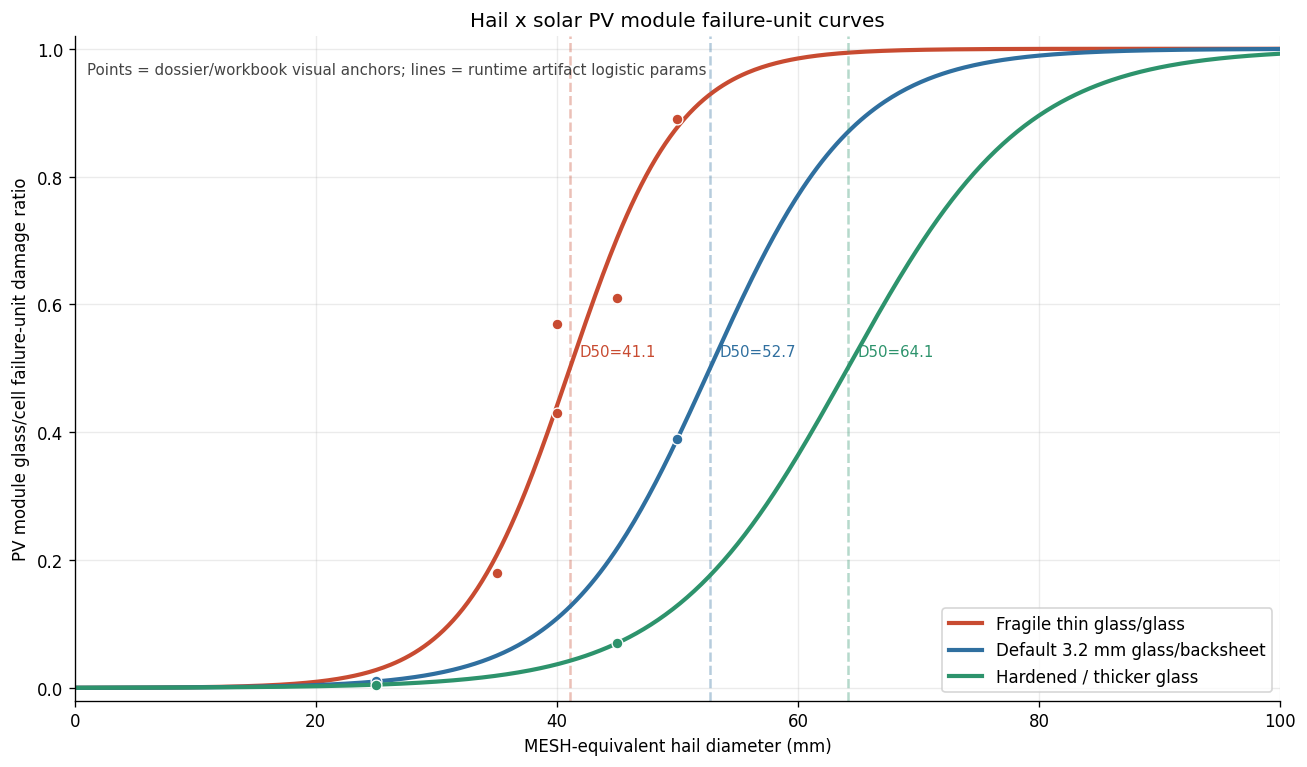

In [6]:
diameters = np.linspace(0, 100, 501)

labels = {
    "HAIL_SOLAR_FRAGILE_THIN_GG": "Fragile thin glass/glass",
    "HAIL_SOLAR_DEFAULT_3P2_GBS": "Default 3.2 mm glass/backsheet",
    "HAIL_SOLAR_HARDENED_THICKER": "Hardened / thicker glass",
}
colors = {
    "HAIL_SOLAR_FRAGILE_THIN_GG": "#c84b31",
    "HAIL_SOLAR_DEFAULT_3P2_GBS": "#2f6f9f",
    "HAIL_SOLAR_HARDENED_THICKER": "#2d936c",
}

# Dossier-derived anchor annotations for reviewer orientation.
anchor_points = pd.DataFrame([
    {"curve_id": "HAIL_SOLAR_DEFAULT_3P2_GBS", "D_mm": 25, "p": 0.01, "source": "IEC baseline near-zero"},
    {"curve_id": "HAIL_SOLAR_DEFAULT_3P2_GBS", "D_mm": 50, "p": 0.39, "source": "PVEL 2023 GBS"},
    {"curve_id": "HAIL_SOLAR_FRAGILE_THIN_GG", "D_mm": 35, "p": 0.18, "source": "PVEL 2023 thin GG"},
    {"curve_id": "HAIL_SOLAR_FRAGILE_THIN_GG", "D_mm": 40, "p": 0.57, "source": "PVEL 2023 thin GG"},
    {"curve_id": "HAIL_SOLAR_FRAGILE_THIN_GG", "D_mm": 40, "p": 0.43, "source": "Kiwa/PVEL thin GG"},
    {"curve_id": "HAIL_SOLAR_FRAGILE_THIN_GG", "D_mm": 45, "p": 0.61, "source": "Kiwa/PVEL thin GG"},
    {"curve_id": "HAIL_SOLAR_FRAGILE_THIN_GG", "D_mm": 50, "p": 0.89, "source": "PVEL 2023 thin GG"},
    {"curve_id": "HAIL_SOLAR_HARDENED_THICKER", "D_mm": 25, "p": 0.005, "source": "IEC hardened near-zero assumption"},
    {"curve_id": "HAIL_SOLAR_HARDENED_THICKER", "D_mm": 45, "p": 0.07, "source": "PVEL/Kiwa hardened public result"},
])

fig, ax = plt.subplots(figsize=(11, 6.5))
for rec in artifact["curve_records"]:
    params = rec["parameters"]
    curve_id = rec["curve_id"]
    dr = logistic(diameters, params["D50_mm"], params["k_per_mm"], params.get("max_DR", 1.0))
    ax.plot(diameters, dr, lw=2.5, color=colors[curve_id], label=labels[curve_id])
    ax.axvline(params["D50_mm"], color=colors[curve_id], linestyle="--", alpha=0.35)
    ax.text(params["D50_mm"] + 0.8, 0.52, f"D50={params['D50_mm']:.1f}", color=colors[curve_id], fontsize=9)

for curve_id, group in anchor_points.groupby("curve_id"):
    ax.scatter(group["D_mm"], group["p"], s=42, color=colors[curve_id], edgecolor="white", linewidth=0.8, zorder=5)

ax.set_title("Hail x solar PV module failure-unit curves")
ax.set_xlabel("MESH-equivalent hail diameter (mm)")
ax.set_ylabel("PV module glass/cell failure-unit damage ratio")
ax.set_xlim(0, 100)
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="lower right")
ax.text(1, 0.96, "Points = dossier/workbook visual anchors; lines = runtime artifact logistic params", fontsize=9, color="#444")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_base_archetype_curves.png", dpi=180, bbox_inches="tight")
plt.show()


## 6. Selector Logic: Which Curve Do We Use?

`module_archetype` is a fixed asset selector. It is chosen from module construction evidence, not from the event.

If exact module/BOM test data exists, a future version can override these generic archetypes. In v1, the default path is to map available module metadata to one of the three archetypes and flag when the default was used.


In [7]:
selector_logic = pd.DataFrame(artifact["selector_logic"])
display(selector_logic)

selector_examples = pd.DataFrame([
    {
        "available_metadata": "unknown modern utility-scale module",
        "module_archetype": "default_3_2mm_glass_backsheet",
        "curve_id": select_curve_record("default_3_2mm_glass_backsheet")["curve_id"],
        "status": "default; flag if no asset metadata",
    },
    {
        "available_metadata": "2.0 mm glass/glass, thin construction",
        "module_archetype": "fragile_thin_glass_glass",
        "curve_id": select_curve_record("fragile_thin_glass_glass")["curve_id"],
        "status": "use if supported by module metadata",
    },
    {
        "available_metadata": "enhanced hail certification or thicker/hardened glass",
        "module_archetype": "hail_hardened_thicker_glass",
        "curve_id": select_curve_record("hail_hardened_thicker_glass")["curve_id"],
        "status": "use only with supporting evidence",
    },
])
display(selector_examples)


,field,required,default,effect,missing_data_flag
0,module_archetype,True,default_3_2mm_glass_backsheet,chooses_curve_family,DEFAULT_SELECTOR_USED
1,front_glass_thickness_mm,False,NaN,maps_to_module_archetype,NaN
2,glass_glass_vs_backsheet,False,NaN,maps_to_module_archetype,NaN
3,hail_test_rating,False,NaN,can_create_exact_override,NaN


,available_metadata,module_archetype,curve_id,status
0,unknown modern utility-scale module,default_3_2mm_glass_backsheet,HAIL_SOLAR_DEFAULT_3P2_GBS,default; flag if no asset metadata
1,"2.0 mm glass/glass, thin construction",fragile_thin_glass_glass,HAIL_SOLAR_FRAGILE_THIN_GG,use if supported by module metadata
2,enhanced hail certification or thicker/hardened glass,hail_hardened_thicker_glass,HAIL_SOLAR_HARDENED_THICKER,use only with supporting evidence


## 7. Conditioner Logic: Stow Changes The Curve During The Event

`stow_state` is an event-time conditioner. It is not a module archetype, and it is not hail frequency.

The current artifact uses:

```text
DR = P(stowed) * [0.90 * logistic(D; D50 + 8mm, k)] + (1 - P(stowed)) * logistic(D; D50, k)
```

Evidence status: public sources support the **direction** of stow benefit, but the `+8 mm` shift and `0.90` multiplier are placeholder magnitudes. Treat this as useful V1 mechanics, not tracker-specific calibration.


,adjustment_id,field,adjustment_type,form,source_ids,tier,reasoning,open_seam
0,HAIL_STOW_HORIZONTAL_SHIFT_V1,stow_state,probability_blend_of_unstowed_and_stowed_curves,"DR = P_stowed * [0.90 * logistic(D; D50+8mm, k)] + (1-P_stowed) * logistic(D; D50, k)","[E_VDE_HAIL_STOW, DOE_FEMP_HAIL_GUIDANCE]",T4_placeholder_or_expert_judgment,"Public sources support high-tilt/stow reducing normal impact severity, but do not provide a universal numeric shift....",replace with tracker/BOM-specific hail-stow test data


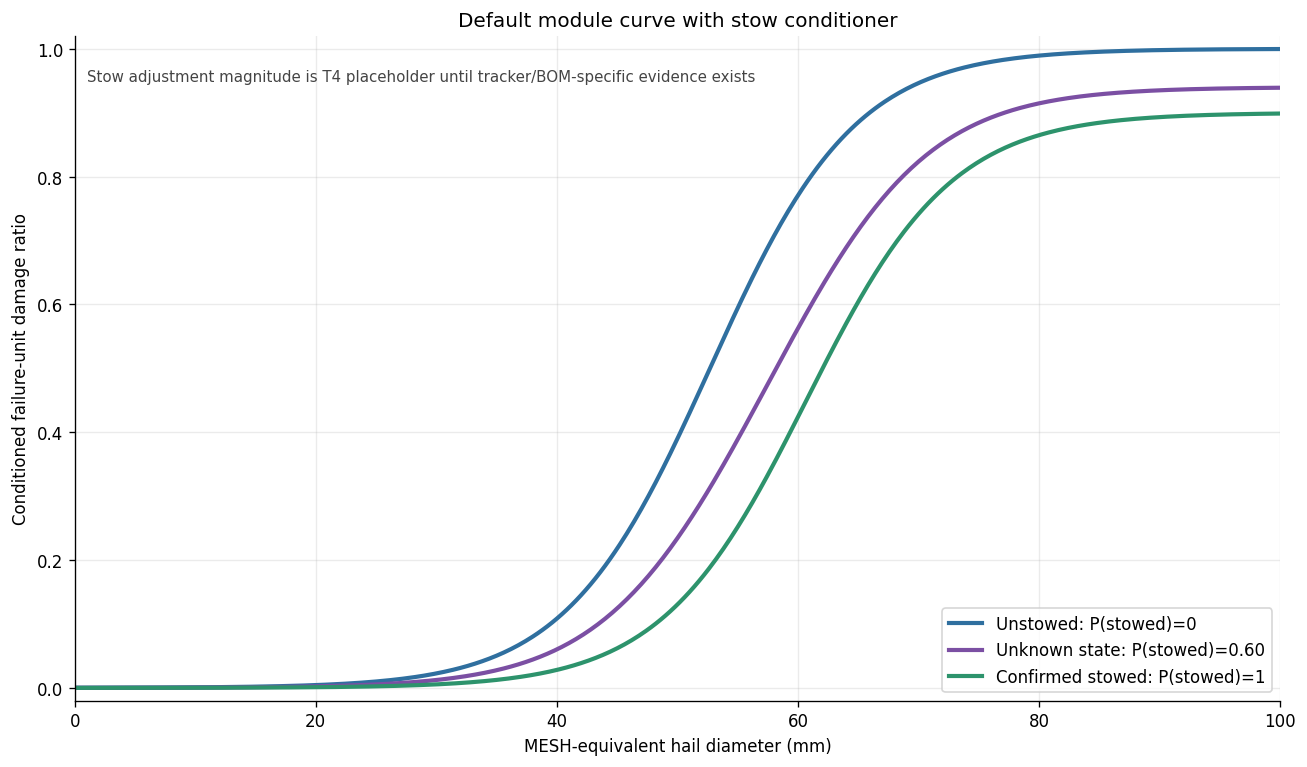

In [8]:
conditioners = pd.DataFrame(artifact["conditioner_logic"])
display(conditioners)

fig, ax = plt.subplots(figsize=(11, 6.5))
for state, p, label, color in [
    ("unstowed", None, "Unstowed: P(stowed)=0", "#2f6f9f"),
    ("unknown_probabilistic", 0.60, "Unknown state: P(stowed)=0.60", "#7b4fa3"),
    ("stowed", None, "Confirmed stowed: P(stowed)=1", "#2d936c"),
]:
    y = evaluate_failure_unit_dr(
        diameters,
        module_archetype="default_3_2mm_glass_backsheet",
        stow_state=state,
        stow_success_probability=p,
    )
    ax.plot(diameters, y, lw=2.5, color=color, label=label)

ax.set_title("Default module curve with stow conditioner")
ax.set_xlabel("MESH-equivalent hail diameter (mm)")
ax.set_ylabel("Conditioned failure-unit damage ratio")
ax.set_xlim(0, 100)
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="lower right")
ax.text(1, 0.95, "Stow adjustment magnitude is T4 placeholder until tracker/BOM-specific evidence exists", fontsize=9, color="#444")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_stow_conditioner_curves.png", dpi=180, bbox_inches="tight")
plt.show()


## 8. Exposure Logic: Value Touched After A Hit

`array_exposure_fraction` is easy to confuse with `p_hit`, so keep the order straight:

1. Hazard M2/M4 decides whether the event hits the asset (`p_hit`, Bernoulli sampling).
2. Conditional on a hit, M3 evaluates the failure-unit DR at the event hail size.
3. `array_exposure_fraction` scales the value touched by the damaging swath.

For current V1 full-site examples, this fraction is often `1.0`. That is an exposure simplification, not a change to the fragility curve.


,field,required,default,effect
0,array_exposure_fraction,True,1.0,scales affected PV module value


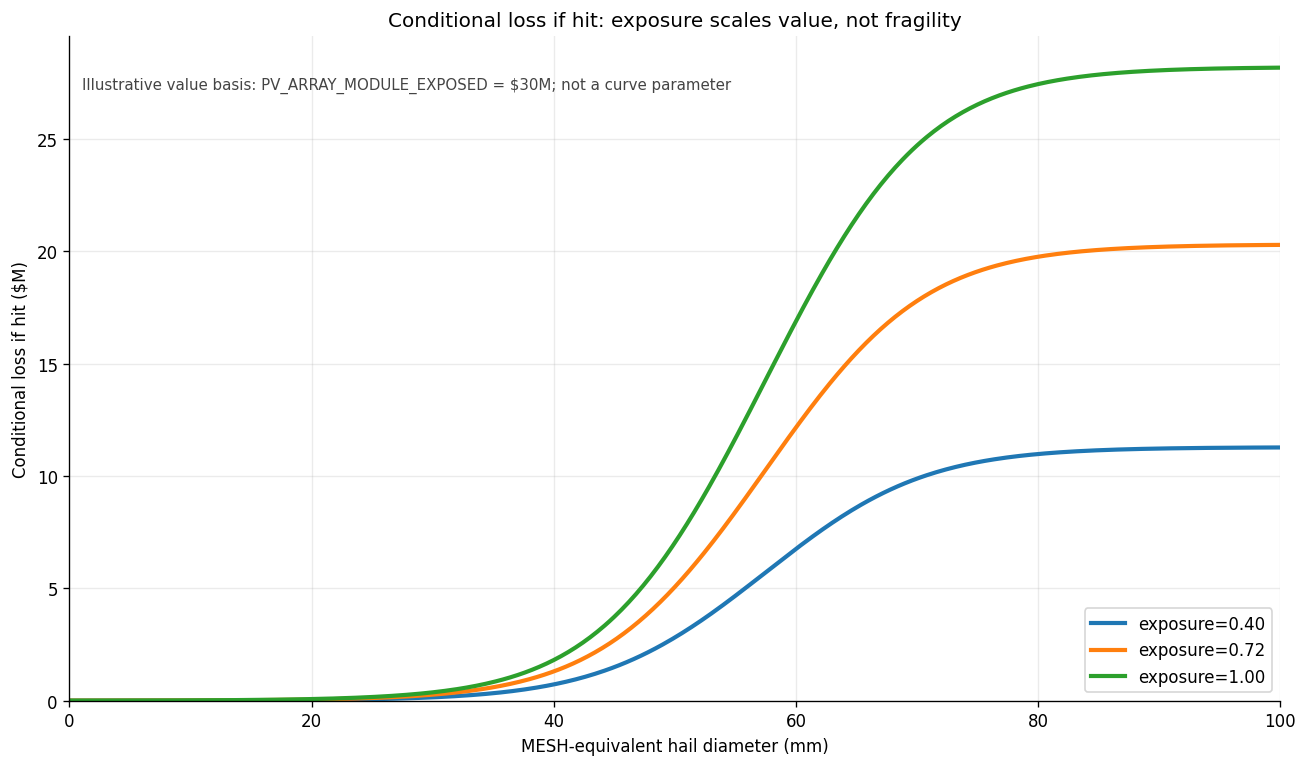

In [9]:
exposure_logic = pd.DataFrame(artifact["exposure_logic"])
display(exposure_logic)

# Consumer-supplied illustrative value basis.
# This is NOT a curve parameter and NOT a statement about all solar plants.
EXAMPLE_VALUE_BASIS_USD = {
    "PV_ARRAY_MODULE_EXPOSED": 30_000_000,
}

loss_rows = []
for exposure in [1.00, 0.72, 0.40]:
    dr = evaluate_failure_unit_dr(
        diameters,
        module_archetype="default_3_2mm_glass_backsheet",
        stow_state="unknown_probabilistic",
        stow_success_probability=0.60,
    )
    loss = dr * exposure * EXAMPLE_VALUE_BASIS_USD["PV_ARRAY_MODULE_EXPOSED"]
    for d, y, l in zip(diameters, dr, loss):
        loss_rows.append({"diameter_mm": d, "exposure_fraction": exposure, "dr": y, "conditional_loss_usd": l})
loss_df = pd.DataFrame(loss_rows)

fig, ax = plt.subplots(figsize=(11, 6.5))
for exposure, group in loss_df.groupby("exposure_fraction"):
    ax.plot(group["diameter_mm"], group["conditional_loss_usd"] / 1_000_000, lw=2.5, label=f"exposure={exposure:.2f}")

ax.set_title("Conditional loss if hit: exposure scales value, not fragility")
ax.set_xlabel("MESH-equivalent hail diameter (mm)")
ax.set_ylabel("Conditional loss if hit ($M)")
ax.set_xlim(0, 100)
ax.set_ylim(bottom=0)
ax.legend(loc="lower right")
ax.text(
    1,
    ax.get_ylim()[1] * 0.92,
    "Illustrative value basis: PV_ARRAY_MODULE_EXPOSED = $30M; not a curve parameter",
    fontsize=9,
    color="#444",
)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_exposure_conditional_loss_example.png", dpi=180, bbox_inches="tight")
plt.show()


### Value-Basis Note: Direct Bucket vs Subsystem Share

There are two clean ways for a consumer to connect the failure-unit DR to asset dollars:

1. **Direct value bucket available:** use `PV_ARRAY_MODULE_EXPOSED` directly.
2. **Only subsystem value available:** derive the exposed module bucket as `PV_ARRAY_value * f_hail_material_share`.

The second path is a value-link assumption, not a curve parameter. The artifact says the failure-unit uses `f_kind = material_share`, but it does not supply a universal `f_hail_material_share` default. That number should come from the asset valuation ledger, EPC cost breakdown, or an explicit M3 assumption.


In [10]:
value_link_patterns = pd.DataFrame([
    {
        "consumer_has": "PV_ARRAY_MODULE_EXPOSED value bucket",
        "formula": "loss = DR * array_exposure_fraction * PV_ARRAY_MODULE_EXPOSED_value",
        "status": "preferred when valuation ledger has this bucket",
    },
    {
        "consumer_has": "PV_ARRAY subsystem value only",
        "formula": "loss = DR * array_exposure_fraction * PV_ARRAY_value * f_hail_material_share",
        "status": "valid, but f_hail_material_share must be sourced or explicitly assumed",
    },
])
display(value_link_patterns)

# Numeric equivalence example: these two rows intentionally use values that map to the same exposed bucket.
dr_50 = float(evaluate_failure_unit_dr(
    50.0,
    module_archetype="default_3_2mm_glass_backsheet",
    stow_state="unknown_probabilistic",
    stow_success_probability=0.60,
))
exposure = 1.0
example_value_link = pd.DataFrame([
    {
        "path": "direct bucket",
        "PV_ARRAY_MODULE_EXPOSED_$M": 30.0,
        "PV_ARRAY_$M": None,
        "f_hail_material_share": None,
        "DR_at_50mm": dr_50,
        "conditional_loss_$M": dr_50 * exposure * 30.0,
    },
    {
        "path": "PV_ARRAY * f_hail_material_share",
        "PV_ARRAY_MODULE_EXPOSED_$M": 40.0 * 0.75,
        "PV_ARRAY_$M": 40.0,
        "f_hail_material_share": 0.75,
        "DR_at_50mm": dr_50,
        "conditional_loss_$M": dr_50 * exposure * 40.0 * 0.75,
    },
])
display(example_value_link.style.format({"DR_at_50mm": "{:.3f}", "conditional_loss_$M": "${:.2f}"}))


,consumer_has,formula,status
0,PV_ARRAY_MODULE_EXPOSED value bucket,loss = DR * array_exposure_fraction * PV_ARRAY_MODULE_EXPOSED_value,preferred when valuation ledger has this bucket
1,PV_ARRAY subsystem value only,loss = DR * array_exposure_fraction * PV_ARRAY_value * f_hail_material_share,"valid, but f_hail_material_share must be sourced or explicitly assumed"


,path,PV_ARRAY_MODULE_EXPOSED_$M,PV_ARRAY_$M,f_hail_material_share,DR_at_50mm,conditional_loss_$M
0,direct bucket,30.000000,nan,nan,0.234,$7.03
1,PV_ARRAY * f_hail_material_share,30.000000,40.000000,0.750000,0.234,$7.03


## 9. Consumer-Style Example For Current Hazard M3

A Hazard M3 consumer should pass event intensity and asset metadata into the damage code, then apply the returned DR to the correct value bucket.

For a current V1 full-exposure solar example, the consumer input might say:

```text
mesh_diameter_mm = event severity from M2
module_archetype = default_3_2mm_glass_backsheet unless better module metadata exists
stow_state = unknown_probabilistic if event-time state is unknown
stow_success_probability = explicit assumption or asset operational data
array_exposure_fraction = 1.0 for full exposure on hit V1
value_basis_usd[PV_ARRAY_MODULE_EXPOSED] = asset valuation ledger bucket
```

The example value basis below is illustrative so the mechanics are visible. It should be replaced by the asset's valuation ledger in a production M3 run.


In [11]:
example_payload = {
    "mesh_diameter_mm": 50.0,
    "module_archetype": "default_3_2mm_glass_backsheet",
    "stow_state": "unknown_probabilistic",
    "stow_success_probability": 0.60,
    "array_exposure_fraction": 1.00,
    "value_basis_usd": EXAMPLE_VALUE_BASIS_USD,
}

result = evaluate_damage_code(example_payload)
result_display = pd.DataFrame([
    {"field": key, "value": value}
    for key, value in result.items()
])
display(result_display)

scenario_sizes = [25, 35, 45, 50, 55, 65, 75, 90]
scenario_rows = []
for size in scenario_sizes:
    payload = {**example_payload, "mesh_diameter_mm": float(size)}
    row = evaluate_damage_code(payload)
    scenario_rows.append({
        "mesh_mm": size,
        "curve_id": row["curve_id"],
        "p_stowed_conditioner": row["p_stowed_conditioner"],
        "exposure_fraction": row["array_exposure_fraction"],
        "failure_unit_DR": row["failure_unit_damage_ratio"],
        "conditional_loss_$M": row["conditional_loss_if_hit_usd"] / 1_000_000,
    })
scenario_table = pd.DataFrame(scenario_rows)
display(scenario_table.style.format({"failure_unit_DR": "{:.3f}", "conditional_loss_$M": "${:.2f}"}))


,field,value
0,damage_code_id,HAIL_SOLAR_PV_MODULE_V1
1,curve_id,HAIL_SOLAR_DEFAULT_3P2_GBS
2,failure_unit_id,PV_MODULE_GLASS_CELL
3,mesh_diameter_mm,50.0
4,module_archetype,default_3_2mm_glass_backsheet
5,stow_state,unknown_probabilistic
6,p_stowed_conditioner,0.6
7,array_exposure_fraction,1.0
8,failure_unit_damage_ratio,0.234286
9,value_bucket,PV_ARRAY_MODULE_EXPOSED


,mesh_mm,curve_id,p_stowed_conditioner,exposure_fraction,failure_unit_DR,conditional_loss_$M
0,25,HAIL_SOLAR_DEFAULT_3P2_GBS,0.600000,1.000000,0.005,$0.16
1,35,HAIL_SOLAR_DEFAULT_3P2_GBS,0.600000,1.000000,0.028,$0.83
2,45,HAIL_SOLAR_DEFAULT_3P2_GBS,0.600000,1.000000,0.124,$3.73
3,50,HAIL_SOLAR_DEFAULT_3P2_GBS,0.600000,1.000000,0.234,$7.03
4,55,HAIL_SOLAR_DEFAULT_3P2_GBS,0.600000,1.000000,0.389,$11.67
5,65,HAIL_SOLAR_DEFAULT_3P2_GBS,0.600000,1.000000,0.717,$21.50
6,75,HAIL_SOLAR_DEFAULT_3P2_GBS,0.600000,1.000000,0.884,$26.53
7,90,HAIL_SOLAR_DEFAULT_3P2_GBS,0.600000,1.000000,0.935,$28.05


## 10. Capability Declaration: What Metrics Are Honest From This Artifact?

The artifact supports scalar failure-unit DR and scenario loss given explicit value/exposure basis.

It does **not** carry a damage-ratio distribution or tail/spread information. Therefore the artifact itself withholds PML/VaR/TVaR. A downstream Hazard model can still compute annual risk metrics after combining frequency, hit sampling, value basis, and an approved severity/tail treatment, but that is outside this damage notebook.


In [12]:
cap = artifact["capability_declaration"]
metrics = pd.DataFrame([
    {"metric_or_emit": key, "status": value}
    for key, value in cap["metrics_supportable"].items()
])
display(metrics)

display(pd.DataFrame([
    {"field": key, "value": value}
    for key, value in cap["cap_binding"].items()
]))


,metric_or_emit,status
0,failure_unit_scalar_dr,supported
1,scenario_loss_given_value_basis,supported_with_explicit_value_and_exposure_basis
2,scalar_eal,conditional_require_cap_binding_preflight
3,pml,withheld_no_tail_distribution
4,var,withheld_no_tail_distribution
5,tvar,withheld_no_tail_distribution


,field,value
0,policy,fail_closed
1,preflight_status,not_executed_no_downstream_frequency_or_state_distribution
2,required_before_scalar_eal,True
3,tolerance_pct,2.5
4,action_if_fail,require_mean_plus_spread_emit
5,reason,Current package contains severity curves but not downstream hazard/state distributions or project-specific cap tests.


## 11. What This Notebook Teaches, And What It Cannot Teach Yet

This notebook is good for:

- reading the canonical runtime artifact;
- understanding failure-unit grain;
- seeing how evidence-supported curve parameters differ from placeholder adjustments;
- seeing the difference between selector, conditioner, and exposure;
- understanding how M3 conditional loss should be assembled for hail x solar.

It is not enough for every future cell because hail x solar v1 has only one primary nonzero failure-unit. The next useful walkthroughs should deliberately exercise other shapes:

- `flood_solar`: multiple failure-units and elevation/exposure geometry;
- `wind_tornado_wind`: repeated turbine units, structural curves, and gust-basis bridges;
- future hail x solar integration: replacing the legacy Hazard M3 capex blend with this canonical failure-unit artifact.
